# Calculating SFC across models

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
import pickle as pk

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
import lfp_utils as lu
from bootstrap_method import *
import population_utils as pu

import sfc_utils as sfc


2025-10-07 12:26:26.756700: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 12:26:26.766681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-07 12:26:26.776893: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-07 12:26:26.779910: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 12:26:26.788482: I tensorflow/core/platform/cpu_feature_guar

## Load models

In [2]:
delay = 400 
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

theta4_dirs = [m for m in model_dirs if '4.0' in m] # 4Hz models only
# theta8_dirs = [m for m in model_dirs if '8.0' in m] # 8Hz models only

print(f'Number of 4Hz models: {len(theta4_dirs)}')

perfs = []
for model_name in theta4_dirs:
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    perfs.append(np.mean(trial_perfs))
    print(f'Model {model_name}, performance: {np.mean(trial_perfs):.2f}')

Number of 4Hz models: 22
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038, performance: 0.85
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100, performance: 0.98
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821, performance: 0.99
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248, performance: 0.56
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726, performance: 0.97
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121802, performance: 0.96
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736, performance: 0.72
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559, performance: 0.91
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527, performance: 0.84
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653, performance: 0.94
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450, performance: 1.00
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025

## SFC across-model plots

#### how many neurons included in the analysis

In [4]:
n_neurons_with_plv = []
for model_name in theta4_dirs:
    model_dir = os.path.join(all_models_dir, model_name)
    file_name = os.path.join(model_dir, f'SFC_delay{delay}_trialPLVs.pkl')
    
    with open(file_name, 'rb') as f:
        trialPLVs = pk.load(f)
    trial_plvs = trialPLVs['trial_plvs']
    null_plvs = trialPLVs['null_plvs']
    trial_plvs_z = trialPLVs['trial_plvs_z']
    n_trial_spikes = trialPLVs['n_trial_spikes']
    del trialPLVs
    
    print(f'Model {model_name}, {np.sum(~np.isnan(np.nanmean(trial_plvs, axis=1)))} neurons with PLVs, {trial_plvs.shape}, {null_plvs.shape}, {trial_plvs_z.shape}, {n_trial_spikes.shape}')
    n_neurons_with_plv.append(np.sum(~np.isnan(np.nanmean(trial_plvs, axis=1))))


/tmp/ipykernel_1556812/90257342.py:14: RuntimeWarning: Mean of empty slice
  print(f'Model {model_name}, {np.sum(~np.isnan(np.nanmean(trial_plvs, axis=1)))} neurons with PLVs, {trial_plvs.shape}, {null_plvs.shape}, {trial_plvs_z.shape}, {n_trial_spikes.shape}')
/tmp/ipykernel_1556812/90257342.py:15: RuntimeWarning: Mean of empty slice
  n_neurons_with_plv.append(np.sum(~np.isnan(np.nanmean(trial_plvs, axis=1))))


Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038, 130 neurons with PLVs, (200, 1000), (200, 1000, 100), (200, 1000), (200, 1000)
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100, 153 neurons with PLVs, (200, 1000), (200, 1000, 100), (200, 1000), (200, 1000)
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821, 93 neurons with PLVs, (200, 1000), (200, 1000, 100), (200, 1000), (200, 1000)
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248, 114 neurons with PLVs, (200, 1000), (200, 1000, 100), (200, 1000), (200, 1000)
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726, 113 neurons with PLVs, (200, 1000), (200, 1000, 100), (200, 1000), (200, 1000)
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121802, 94 neurons with PLVs, (200, 1000), (200, 1000, 100), (200, 1000), (200, 1000)
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736, 145 neurons with PLVs, (200, 1000), (200, 1000, 100), (200, 1000),

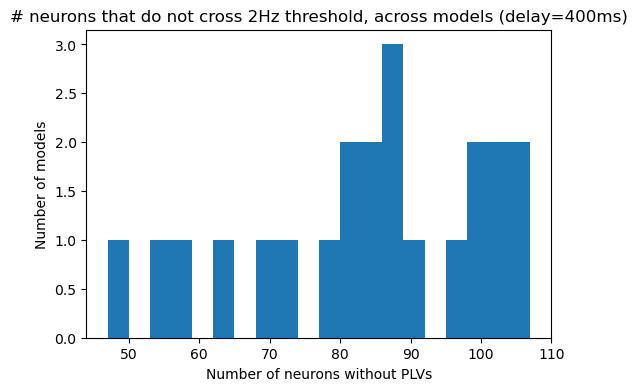

In [5]:
plt.figure(figsize=(6,4))
plt.hist(np.ones(len(n_neurons_with_plv))*200 - np.array(n_neurons_with_plv), bins=20)
plt.xlabel('Number of neurons without PLVs')
plt.ylabel('Number of models')
plt.title(f'# neurons that do not cross 2Hz threshold, across models (delay={delay}ms)')
plt.show()

### PLV for correct vs incorrect trials

In [5]:
from scipy.stats import mannwhitneyu, wilcoxon

/tmp/ipykernel_1363169/3042697305.py:32: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(plv_corr, plv_incor, alternative='two-sided', nan_policy='omit')
/tmp/ipykernel_1363169/3042697305.py:37: RuntimeWarning: Mean of empty slice
  axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, alpha=0.5)


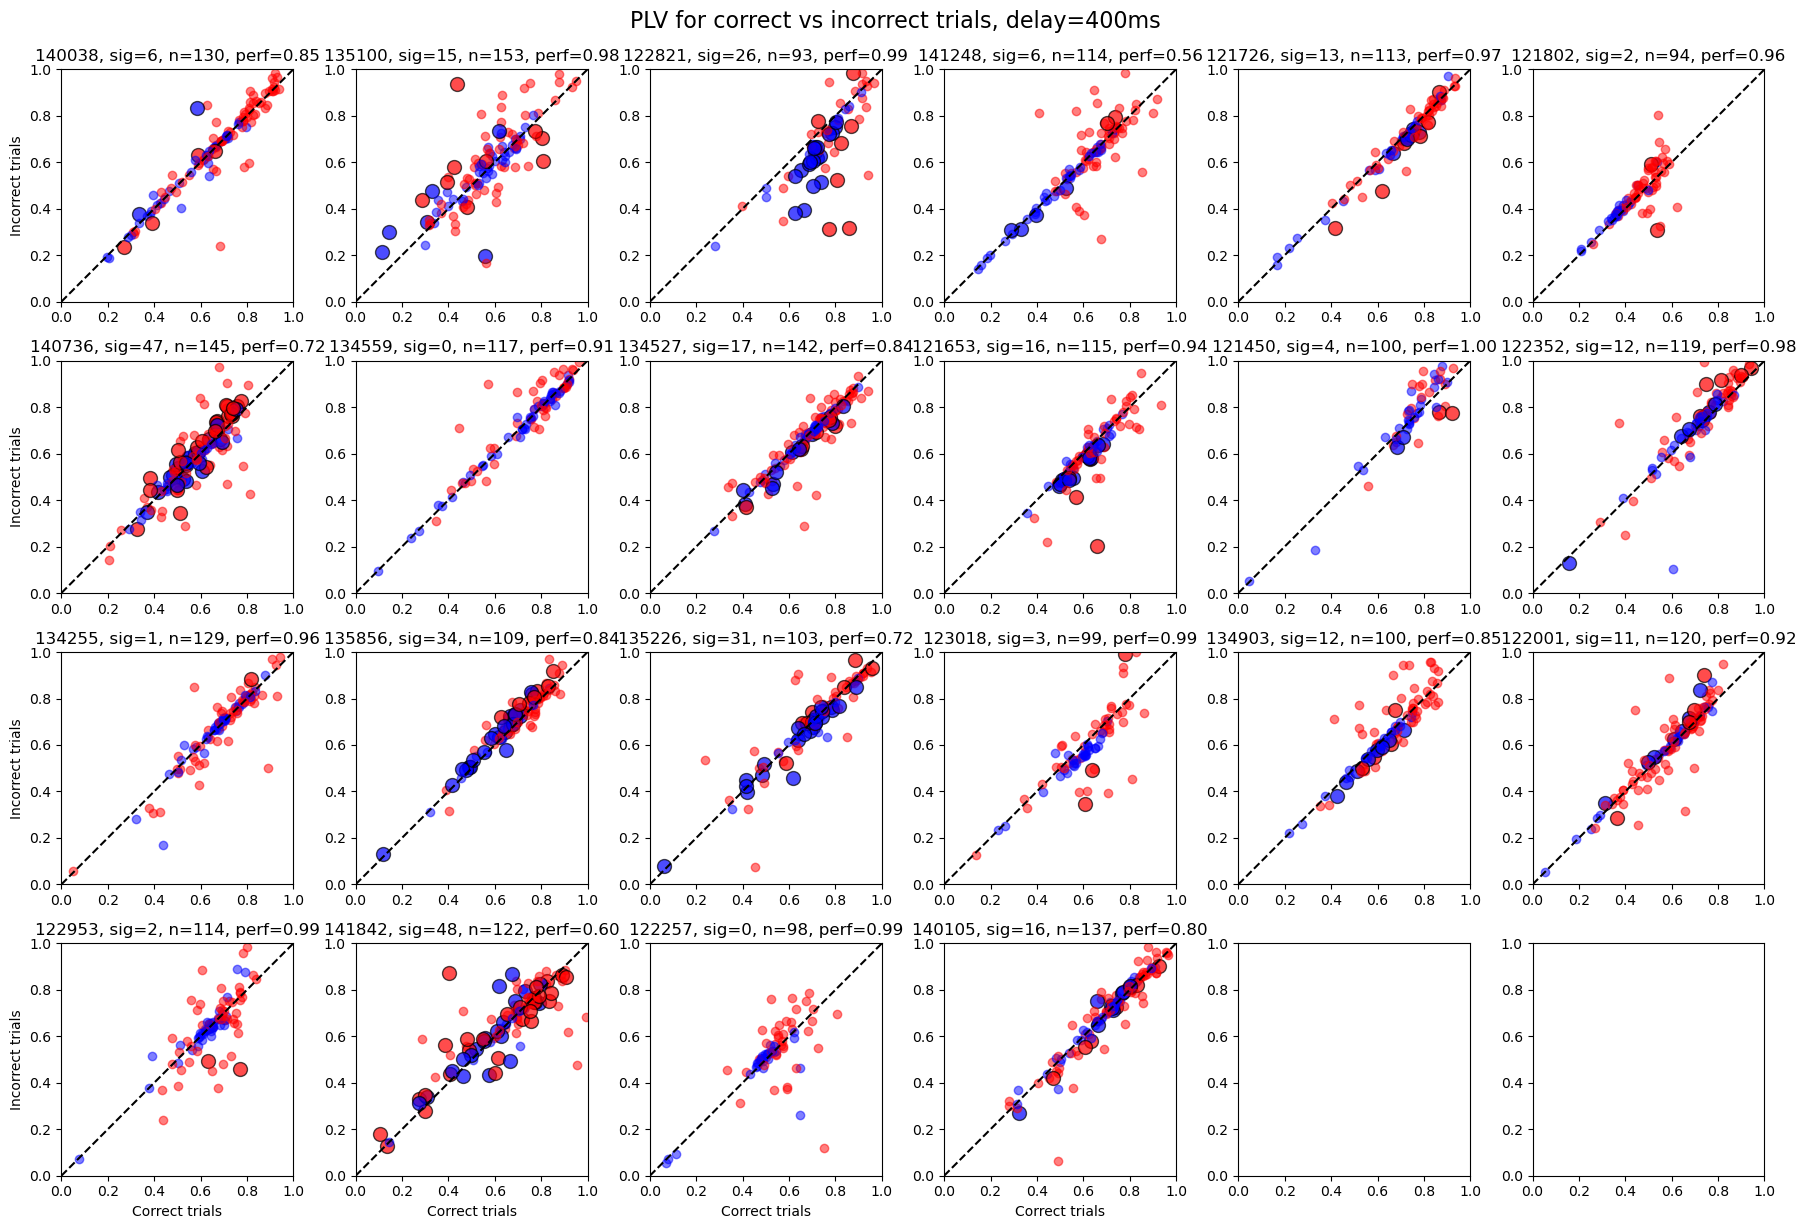

In [ ]:
# plot z-scored PLVs for correct vs incorrect trials

fig, axs = plt.subplots(4, 6, figsize=(18,12))
axs = axs.flatten()

model_sig_neurons = []
for i, model_name in enumerate(theta4_dirs):
    model_dir = os.path.join(all_models_dir, model_name)
    file_name = os.path.join(model_dir, f'SFC_delay{delay}_trialPLVs.pkl')
    
    with open(file_name, 'rb') as f:
        trialPLVs = pk.load(f)
    trial_plvs = trialPLVs['trial_plvs']
    null_plvs = trialPLVs['null_plvs']
    n_trial_spikes = trialPLVs['n_trial_spikes']
    trial_plvs_z = trialPLVs['trial_plvs_z']
    del trialPLVs
    
    
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    
    trial_corr = np.where(trial_perfs == 1)[0]
    trial_incor = np.where(trial_perfs ==0)[0]
    
    if len(trial_incor) == 0:
        print(f'Model {model_name} has no incorrect trials, skipping')
        continue
    
    sig_neurons = []
    for i_neuron in range(trial_plvs_z.shape[0]):
        plv_corr = trial_plvs_z[i_neuron, trial_corr]
        plv_incor = trial_plvs_z[i_neuron, trial_incor]

        c = ['r' if i_neuron in exc_ind else 'b'][0]
        stat, p = mannwhitneyu(plv_corr, plv_incor, alternative='two-sided', nan_policy='omit')
        if p < 0.05:
            axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, edgecolor='k', s=100, alpha=0.7)
            sig_neurons.append(i_neuron)
        else:
            axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, alpha=0.5)
    model_sig_neurons.append(np.array(sig_neurons))
    axs[i].plot([0,1], [0,1], 'k--')
    axs[i].set_xlim([0,1])
    axs[i].set_ylim([0,1])
    axs[i].set_title(f'{model_name[-6:]}, sig={len(sig_neurons)}, n={n_neurons_with_plv[i]}, perf={perfs[i]:.2f}')
    if i % 6 == 0:
        axs[i].set_ylabel('Incorrect trials')
    if i >= 18:
        axs[i].set_xlabel('Correct trials')
plt.tight_layout()
plt.suptitle(f'PLV for correct vs incorrect trials, delay={delay}ms', y=1.02, fontsize=16)
plt.show()

199 neurons with PLV for stim1=-1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038, sig=4
199 neurons with PLV for stim1=1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038, sig=5
199 neurons with PLV for stim1=-1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100, sig=4
199 neurons with PLV for stim1=1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100, sig=1
199 neurons with PLV for stim1=-1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821, sig=8
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821 has no incorrect trials for stim1=1, skipping
0 neurons with PLV for stim1=1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821, sig=0
199 neurons with PLV for stim1=-1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248, sig=5
199 neurons with PLV for stim1=1, model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248, sig=6
199 neurons with PLV for stim1=-1, mode

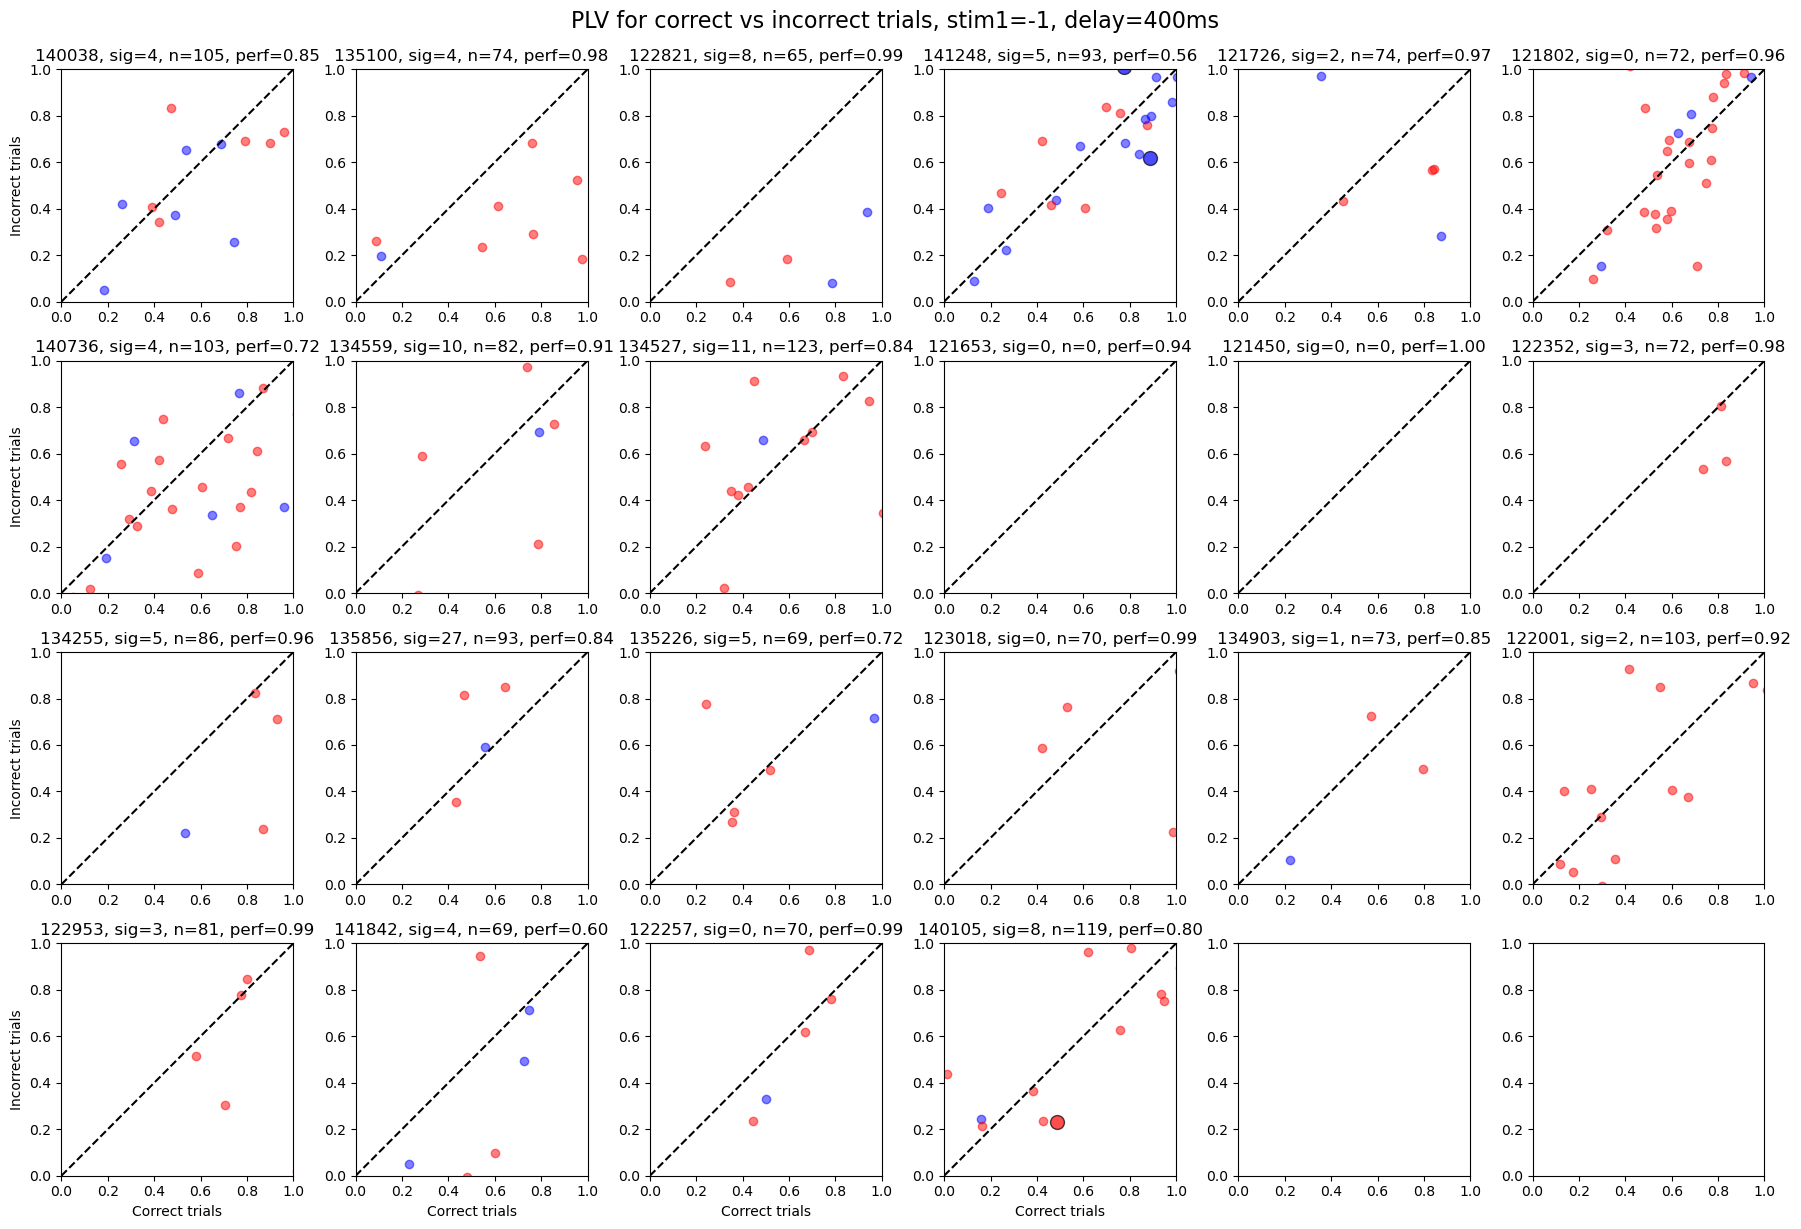

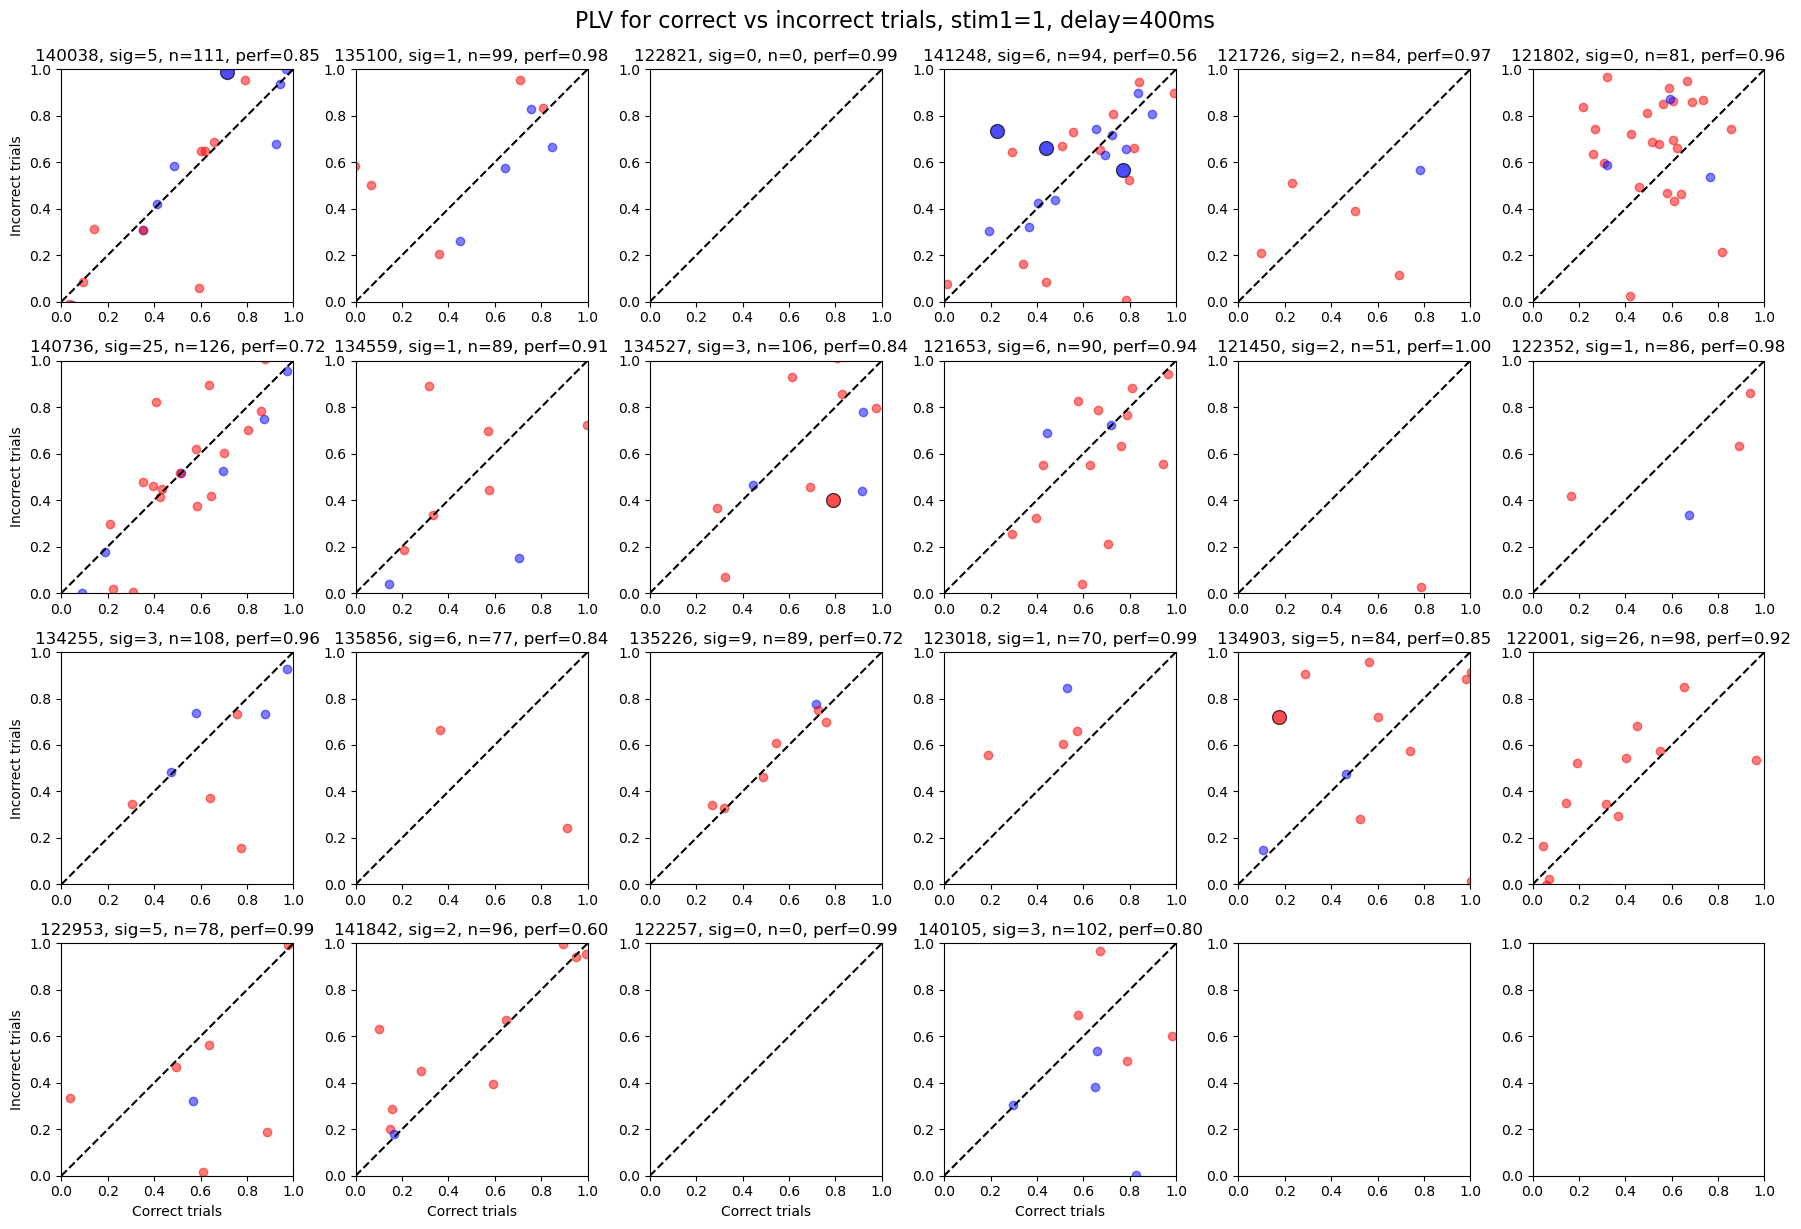

In [ ]:
# plot z-scored PLVs for correct vs incorrect trials, split by +1 and -1

stim1s = [-1, 1]

fig1, axs1 = plt.subplots(4, 6, figsize=(18,12))
axs1 = axs1.flatten()

fig2, axs2 = plt.subplots(4, 6, figsize=(18,12))
axs2 = axs2.flatten()

model_sig_neurons = []
for i, model_name in enumerate(theta4_dirs):
    model_dir = os.path.join(all_models_dir, model_name)
    file_name = os.path.join(model_dir, f'SFC_delay{delay}_trialPLVs.pkl')
    
    with open(file_name, 'rb') as f:
        trialPLVs = pk.load(f)
    trial_plvs = trialPLVs['trial_plvs']
    null_plvs = trialPLVs['null_plvs']
    n_trial_spikes = trialPLVs['n_trial_spikes']
    trial_plvs_z = trialPLVs['trial_plvs_z']
    del trialPLVs
    
    
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    
    trial_corr = np.where(trial_perfs == 1)[0]
    trial_incor = np.where(trial_perfs ==0)[0]
    
    if len(trial_incor) == 0:
        print(f'Model {model_name} has no incorrect trials, skipping')
        continue

    for j, stim1 in enumerate(stim1s):
        if j == 0:
            axs = axs1
        else:
            axs = axs2
            
        stim_idxs = np.where(trial_labels[:,0] == stim1)[0]
        corr_stim_idxs = np.intersect1d(trial_corr, stim_idxs)
        incor_stim_idxs = np.intersect1d(trial_incor, stim_idxs)
        if len(incor_stim_idxs) == 0:
            print(f'Model {model_name} has no incorrect trials for stim1={stim1}, skipping')
            continue

        sig_neurons = []
        n_neurons_with_plv = 0
        for i_neuron in range(trial_plvs_z.shape[0]):
            
            plv_corr = trial_plvs_z[i_neuron, corr_stim_idxs]
            plv_incor = trial_plvs_z[i_neuron, incor_stim_idxs]
            if np.sum(~np.isnan(plv_corr)) == 0 or np.sum(~np.isnan(plv_incor)) == 0: # no non-nan PLVs
                # print(f'Model {model_name} has insufficient data for stim1={stim1}, skipping neuron {i_neuron}')
                continue
            n_neurons_with_plv += 1

            c = ['r' if i_neuron in exc_ind else 'b'][0]
            stat, p = mannwhitneyu(plv_corr, plv_incor, alternative='two-sided', nan_policy='omit')
            if p < 0.05:
                axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, edgecolor='k', s=100, alpha=0.7)
                sig_neurons.append(i_neuron)
            else:
                axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, alpha=0.5)
        model_sig_neurons.append(np.array(sig_neurons))
        axs[i].plot([0,1], [0,1], 'k--')
        axs[i].set_xlim([0,1])
        axs[i].set_ylim([0,1])
        axs[i].set_title(f'{model_name[-6:]}, sig={len(sig_neurons)}, n={n_neurons_with_plv}, perf={perfs[i]:.2f}')
        if i % 6 == 0:
            axs[i].set_ylabel('Incorrect trials')
        if i >= 18:
            axs[i].set_xlabel('Correct trials')
fig1.tight_layout()
fig1.suptitle(f'PLV for correct vs incorrect trials, stim1={stim1s[0]}, delay={delay}ms', y=1.02, fontsize=16)
fig2.tight_layout()
fig2.suptitle(f'PLV for correct vs incorrect trials, stim1={stim1s[1]}, delay={delay}ms', y=1.02, fontsize=16)
plt.show()


In [15]:
np.nanmean(plv_incor)

0.500320680147599

In [13]:
np.nanmean(plv_corr)

0.7013926217067196

/tmp/ipykernel_1433468/1281069961.py:34: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(plv_corr, plv_incor, alternative='two-sided', nan_policy='omit')
/tmp/ipykernel_1433468/1281069961.py:39: RuntimeWarning: Mean of empty slice
  axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, alpha=0.5)


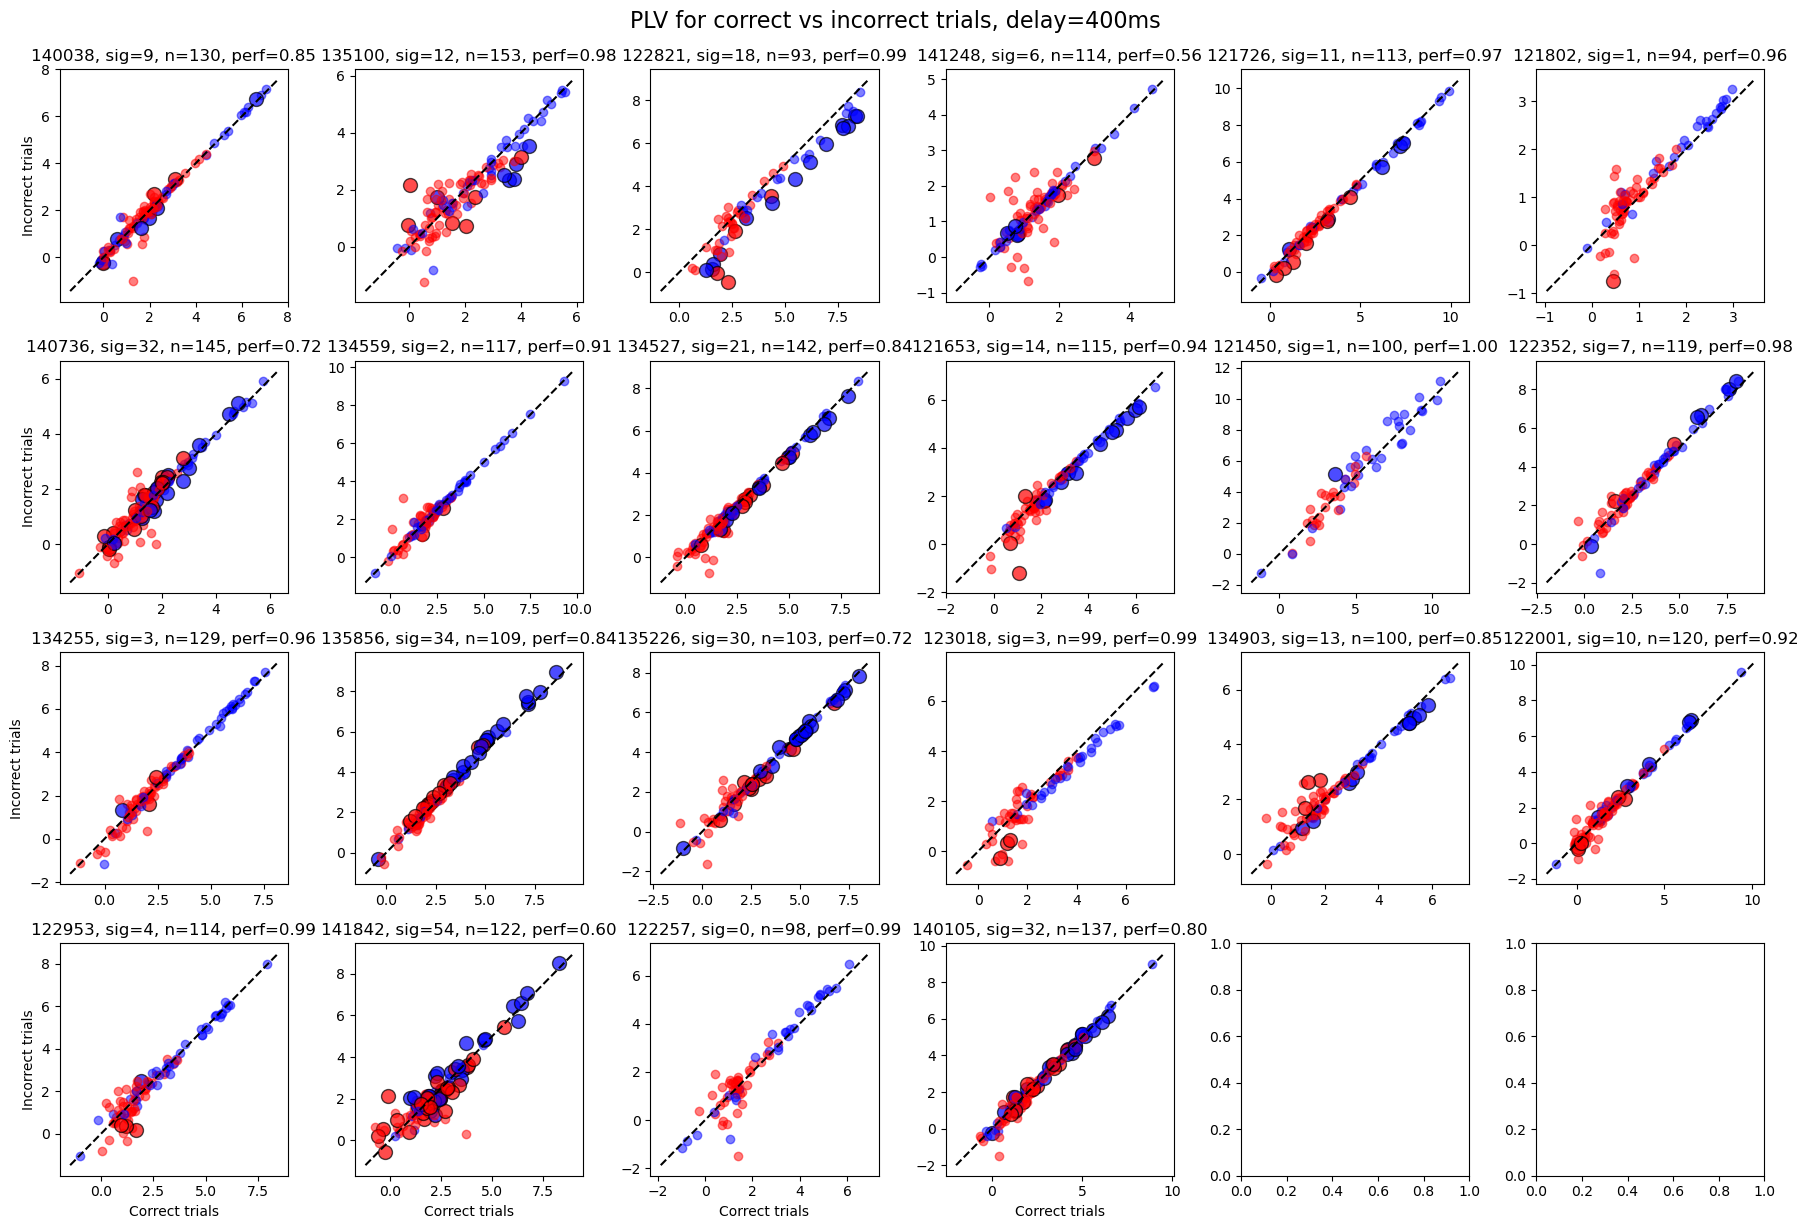

In [ ]:
# non-zsored plots, old

fig, axs = plt.subplots(4, 6, figsize=(18,12))
axs = axs.flatten()

model_sig_neurons = []
for i, model_name in enumerate(theta4_dirs):
    model_dir = os.path.join(all_models_dir, model_name)
    file_name = os.path.join(model_dir, f'SFC_delay{delay}_trialPLVs.pkl')
    
    with open(file_name, 'rb') as f:
        trialPLVs = pk.load(f)
    trial_plvs = trialPLVs['trial_plvs']
    null_plvs = trialPLVs['null_plvs']
    n_trial_spikes = trialPLVs['n_trial_spikes']
    trial_plvs_z = trialPLVs['trial_plvs_z']
    del trialPLVs
    
    
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    
    trial_corr = np.where(trial_perfs == 1)[0]
    trial_incor = np.where(trial_perfs ==0)[0]
    
    if len(trial_incor) == 0:
        print(f'Model {model_name} has no incorrect trials, skipping')
        continue
    
    sig_neurons = []
    for i_neuron in range(trial_plvs_z.shape[0]):
        plv_corr = trial_plvs_z[i_neuron, trial_corr]
        plv_incor = trial_plvs_z[i_neuron, trial_incor]

        c = ['r' if i_neuron in exc_ind else 'b'][0]
        stat, p = mannwhitneyu(plv_corr, plv_incor, alternative='two-sided', nan_policy='omit')
        if p < 0.05:
            axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, edgecolor='k', s=100, alpha=0.7)
            sig_neurons.append(i_neuron)
        else:
            axs[i].scatter(np.nanmean(plv_corr), np.nanmean(plv_incor), c=c, alpha=0.5)
    model_sig_neurons.append(np.array(sig_neurons))
    xlims = axs[i].get_xlim()
    ylims = axs[i].get_ylim()
    axs[i].plot([min(xlims[0], ylims[0]), max(xlims[1], ylims[1])], [min(xlims[0], ylims[0]), max(xlims[1], ylims[1])], 'k--')
    # axs[i].set_xlim([0,1])
    # axs[i].set_ylim([0,1])
    axs[i].set_title(f'{model_name[-6:]}, sig={len(sig_neurons)}, n={n_neurons_with_plv[i]}, perf={perfs[i]:.2f}')
    if i % 6 == 0:
        axs[i].set_ylabel('Incorrect trials')
    if i >= 18:
        axs[i].set_xlabel('Correct trials')
plt.tight_layout()
plt.suptitle(f'PLV for correct vs incorrect trials, delay={delay}ms', y=1.02, fontsize=16)
plt.show()

In [ ]:
# plot correct vs incorrect trial mean PLV for all neurons

trial_corr = np.where(trial_perfs == 1)[0]
trial_incor = np.where(trial_perfs == 0)[0]

model_sig_neurons = []
sig_neurons = []
plt.figure(figsize=(6,4))
for i_neuron in neuron_ids:
    c = ['r' if exc_bool[i_neuron] else 'b'][0]
    stat, p = mannwhitneyu(trial_plvs[i_neuron, trial_corr], trial_plvs[i_neuron, trial_incor], alternative='two-sided', nan_policy='omit')
    if p < 0.05:
        plt.scatter(np.nanmean(trial_plvs[i_neuron, trial_corr]), np.nanmean(trial_plvs[i_neuron, trial_incor]), c=c, edgecolor='k', s=100, alpha=0.7)
        sig_neurons.append(i_neuron)
    else:
        plt.scatter(np.nanmean(trial_plvs[i_neuron, trial_corr]), np.nanmean(trial_plvs[i_neuron, trial_incor]), c=c, alpha=0.5)
# plt.scatter(np.nanmean(trial_plvs[:, trial_corr], axis=1), np.nanmean(trial_plvs[:, trial_incor], axis=1),c=exc_bool, cmap='bwr', alpha=0.7)
# plt.colorbar(label='Excitatory (1) / Inhibitory (0)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean Correct Trial PLV')
plt.ylabel('Mean Incorrect Trial PLV')
plt.title(f'Mean Correct vs Incorrect Trial PLV for all neurons, perf={np.mean(trial_perfs):.2f}')
plt.show()